<a href="https://colab.research.google.com/github/navirath/ML-lab/blob/main/pca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# generate a python code to read a pdf file take the input from the user and dont show the contents of the file just read it for further operations
import PyPDF2
from google.colab import files

def read_pdf_content(file_path):
    try:
        with open(file_path, 'rb') as file:
            reader = PyPDF2.PdfReader(file)
            # We are reading the file but not displaying its content as requested
            # You can access content, e.g., reader.pages[0].extract_text() if needed for further operations
            print(f"Successfully read PDF file: '{file_path}'. Content is loaded for further operations (not displayed).")
            return reader # Return the reader object for further operations if needed
    except FileNotFoundError:
        print(f"Error: The file '{file_path}' was not found.")
        return None
    except Exception as e:
        print(f"An error occurred: {e}")
        return None

# Get PDF file from the user using a file picker
print("Please upload your PDF file:")
uploaded = files.upload()

if uploaded:
    # Assuming only one file is uploaded, take the first one
    pdf_file_name = list(uploaded.keys())[0]
    print(f"Selected file: {pdf_file_name}")

    # Call the function to read the PDF
    pdf_reader_object = read_pdf_content(pdf_file_name)

    # You can now use pdf_reader_object for further processing without printing the content to the console.
    # For example, to get the number of pages:
    # if pdf_reader_object:
    #     print(f"Number of pages: {len(pdf_reader_object.pages)}")
else:
    print("No file was uploaded.")

Please upload your PDF file:


Saving heart.pdf to heart (1).pdf
Selected file: heart (1).pdf
Successfully read PDF file: 'heart (1).pdf'. Content is loaded for further operations (not displayed).


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Assuming 'df' is your DataFrame from the kernel state
# Create a copy to avoid modifying the original DataFrame directly
df_encoded = df.copy()

# Identify categorical columns for encoding
# Based on the kernel state, 'Sex' and 'ChestPainType' are good candidates
categorical_cols = ['Sex', 'ChestPainType']

# --- Label Encoding ---
# Apply Label Encoding to 'Sex' column
label_encoder = LabelEncoder()
df_encoded['Sex_LabelEncoded'] = label_encoder.fit_transform(df_encoded['Sex'])
print("DataFrame after Label Encoding 'Sex' column:")
print(df_encoded[['Sex', 'Sex_LabelEncoded']].head())
print("\nUnique values and their encodings for 'Sex':")
for i, item in enumerate(label_encoder.classes_):
    print(f"{item} : {i}")


# --- One-Hot Encoding ---
# Apply One-Hot Encoding to 'ChestPainType' column
# We'll use pandas get_dummies for simplicity as it directly integrates with DataFrames
df_encoded = pd.get_dummies(df_encoded, columns=['ChestPainType'], prefix='ChestPainType', drop_first=False)

print("\nDataFrame after One-Hot Encoding 'ChestPainType' column:")
# Display relevant columns to show the effect of one-hot encoding
print(df_encoded[['ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA']].head())


print("\nFull DataFrame head after both encodings:")
print(df_encoded.head())

DataFrame after Label Encoding 'Sex' column:
  Sex  Sex_LabelEncoded
0   M                 1
1   F                 0
2   M                 1
3   F                 0
4   M                 1

Unique values and their encodings for 'Sex':
F : 0
M : 1

DataFrame after One-Hot Encoding 'ChestPainType' column:
   ChestPainType_ASY  ChestPainType_ASY  ChestPainType_ATA  ChestPainType_ATA  \
0                  0              False                  1               True   
1                  0              False                  0              False   
2                  0              False                  1               True   
3                  1               True                  0              False   
4                  0              False                  0              False   

   ChestPainType_NAP  ChestPainType_NAP  ChestPainType_TA  ChestPainType_TA  
0                  0              False                 0             False  
1                  1               True             

In [ ]:
# Apply scaling to features and build classification models
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Assuming X_train, X_test, y_train, y_test are already defined in the kernel state
# from a previous train-test split, as indicated by the kernel state variables.

# --- 1. Apply Scaling ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully.")

# --- 2. Build and Evaluate Classification Models ---
models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear'),
    'SVM': SVC(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

best_accuracy = 0
best_model_name = ''

print("\n--- Model Training and Evaluation ---")
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {accuracy:.4f}")

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model_name = name

print(f"\nBest Model: {best_model_name} with Accuracy: {best_accuracy:.4f}")

Features scaled successfully.

--- Model Training and Evaluation ---
Training Logistic Regression...
Logistic Regression Accuracy: 0.7935
Training SVM...
SVM Accuracy: 0.7880
Training Random Forest...
Random Forest Accuracy: 0.7717

Best Model: Logistic Regression with Accuracy: 0.7935


In [ ]:
from sklearn.metrics import confusion_matrix

# Assuming y_test and y_pred (from the best non-PCA model, i.e., Logistic Regression)
# and y_pred_pca (from the best PCA model, i.e., Logistic Regression (PCA)) are available from previous cells.

print("--- Confusion Matrix for Best Model (No PCA): Logistic Regression ---")
# The y_pred variable from cell w81A2ycQn4jp corresponds to the Logistic Regression model without PCA
cm_no_pca = confusion_matrix(y_test, y_pred)
print(cm_no_pca)

print("\n--- Confusion Matrix for Best Model (With PCA): Logistic Regression (PCA) ---")
# The y_pred_pca variable from cell ubYByXfjo64R corresponds to the Logistic Regression (PCA) model
cm_pca = confusion_matrix(y_test, y_pred_pca)
print(cm_pca)

--- Confusion Matrix for Best Model (No PCA): Logistic Regression ---
[[129  12]
 [ 30  13]]

--- Confusion Matrix for Best Model (With PCA): Logistic Regression (PCA) ---
[[122  19]
 [ 29  14]]


In [ ]:
# Now use PCA to reduce dimensions, retrain your model and see what impact it has on your model
# in terms of accuracy. Keep in mind that many times doing PCA reduces the accuracy but
# computation is much lighter and that's the trade off you need to consider while building models in
# real life.

from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# --- 1. Apply PCA to reduce dimensions ---
# It's good practice to choose n_components based on explained variance, but for this example,
# let's pick a fixed number, say 5, or a number of components that explains a significant variance.
# Given the dataset size, 5 components is a reasonable starting point.
n_components = 5
pca = PCA(n_components=n_components)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Original number of features: {X_train_scaled.shape[1]}")
print(f"Number of features after PCA: {X_train_pca.shape[1]}")
print(f"Explained variance ratio by {n_components} components: {pca.explained_variance_ratio_.sum():.4f}")

# --- 2. Retrain models with PCA-transformed data ---
models_pca = {
    'Logistic Regression (PCA)': LogisticRegression(random_state=42, solver='liblinear'),
    'SVM (PCA)': SVC(random_state=42),
    'Random Forest (PCA)': RandomForestClassifier(random_state=42)
}

best_accuracy_pca = 0
best_model_name_pca = ''

print("\n--- Model Training and Evaluation with PCA ---")
for name, model in models_pca.items():
    print(f"Training {name}...")
    model.fit(X_train_pca, y_train)
    y_pred_pca = model.predict(X_test_pca)
    accuracy_pca = accuracy_score(y_test, y_pred_pca)
    print(f"{name} Accuracy: {accuracy_pca:.4f}")

    if accuracy_pca > best_accuracy_pca:
        best_accuracy_pca = accuracy_pca
        best_model_name_pca = name

print(f"\nBest Model with PCA: {best_model_name_pca} with Accuracy: {best_accuracy_pca:.4f}")

# --- Compare with original results ---
print("\n--- Comparison (Original vs. PCA) ---")
print(f"Original Best Model: {best_model_name} with Accuracy: {best_accuracy:.4f}")
print(f"PCA Best Model: {best_model_name_pca} with Accuracy: {best_accuracy_pca:.4f}")

Original number of features: 11
Number of features after PCA: 5
Explained variance ratio by 5 components: 0.8117

--- Model Training and Evaluation with PCA ---
Training Logistic Regression (PCA)...
Logistic Regression (PCA) Accuracy: 0.7935
Training SVM (PCA)...
SVM (PCA) Accuracy: 0.7935
Training Random Forest (PCA)...
Random Forest (PCA) Accuracy: 0.7391

Best Model with PCA: Logistic Regression (PCA) with Accuracy: 0.7935

--- Comparison (Original vs. PCA) ---
Original Best Model: Logistic Regression with Accuracy: 0.7935
PCA Best Model: Logistic Regression (PCA) with Accuracy: 0.7935


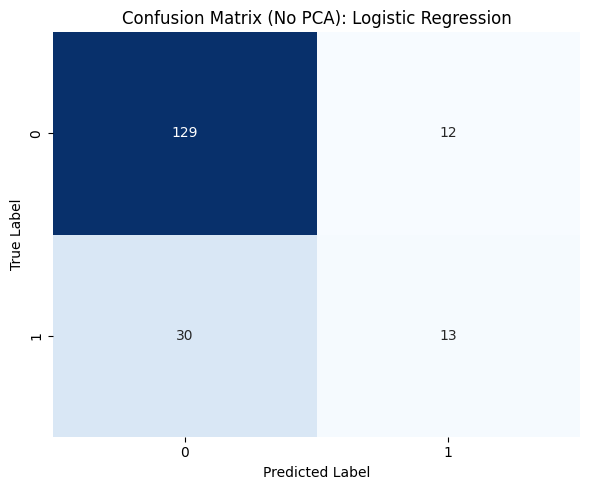

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

# Plot Confusion Matrix for Best Model (No PCA): Logistic Regression
fig_no_pca, ax_no_pca = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_no_pca, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax_no_pca)
ax_no_pca.set_title('Confusion Matrix (No PCA): Logistic Regression')
ax_no_pca.set_xlabel('Predicted Label')
ax_no_pca.set_ylabel('True Label')
plt.tight_layout()
plt.show()

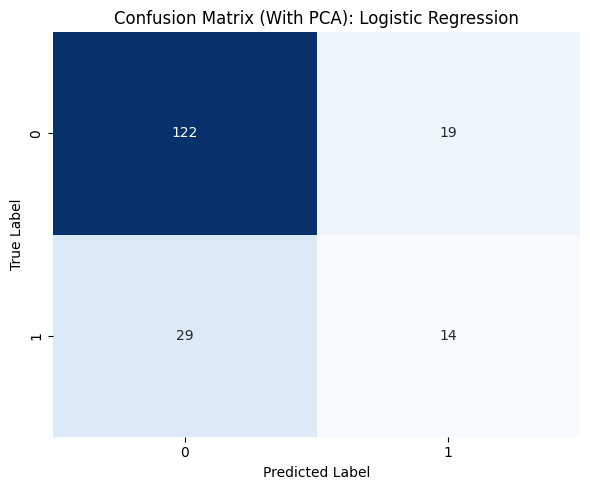

In [ ]:
# Plot Confusion Matrix for Best Model (With PCA): Logistic Regression (PCA)
fig_pca, ax_pca = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_pca, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax_pca)
ax_pca.set_title('Confusion Matrix (With PCA): Logistic Regression')
ax_pca.set_xlabel('Predicted Label')
ax_pca.set_ylabel('True Label')
plt.tight_layout()
plt.show()